In [1]:
import pandas as pd
import bambi
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import pickle as pkl
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import statsmodels.formula.api as smf
import bambi as bmb
import arviz as az

In [2]:
motivation_signal_all = pkl.load(open("../data/generated/all_eids_engagement.pkl", "rb"))
ak_prior_all = pkl.load(open("../data/processed/all_eids_dict_single_zeta_complete_bwm.pkl", "rb"))

In [3]:
# how does the prior interact with the engagement signal
# is it scaled somehow?

In [4]:
def cleanup_data(motivation_signal, trials, session_id):

    scalar = MinMaxScaler()
    engagement_signal = scalar.fit_transform(motivation_signal.reshape(-1, 1)).flatten()
    trials["engagement"] = engagement_signal
    out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(
        trials.contrastRight
    )  # this should keep 0 contrast
    trials["signcont"] = out
    trials["rt"] = trials["firstMovement_times"] - trials["stimOn_times"]
    trials["is_correct"] = (trials["feedbackType"] == 1).astype(int)

    trials_keep = trials[trials["probabilityLeft"] != 0.5][
        [
            "engagement",
            "rt",
            "probabilityLeft",
            "feedbackType",
            "signcont",
            "choice",
            "prior",
            "is_correct",
        ]
    ]
    trials_keep["eid"] = session_id
    trials_keep["is_correct"] = (trials_keep["feedbackType"] == 1).astype(int)
    trials_keep["actual_reward_side"] = np.where(
        trials_keep["is_correct"] == True, trials_keep["choice"], -trials_keep["choice"]
    )
    trials_keep["block_side"] = np.where(trials_keep["probabilityLeft"] == 0.8, 1, -1)
    trials_keep["is_congruent"] = (
        trials_keep["block_side"] == trials_keep["actual_reward_side"]
    ).astype(int)
    return trials_keep

In [5]:
grand_df = []
for idx, eid in enumerate(ak_prior_all.keys()):
    try:
        engagement = motivation_signal_all[eid]
        trial_df = ak_prior_all[eid]
        clean_df = cleanup_data(np.asarray(engagement), trial_df, eid)
        grand_df.append(clean_df)
        if idx == 50:
            break
    except Exception as e:
        print(e)

In [6]:
grand_df = pd.concat(grand_df)

In [19]:
grand_df["prior_strength"] = np.abs(grand_df["prior"] - 0.5) * 2

In [23]:
# grand_df["prior_strength_centered"] = (
#     grand_df["prior_strength"] - grand_df["prior_strength"].mean()
# )

In [22]:
grand_df

,engagement,rt,probabilityLeft,feedbackType,signcont,choice,prior,is_correct,eid,actual_reward_side,block_side,is_congruent,prior_strength,prior_strength_centered
90,0.717114,0.147083,0.8,1.0,-1.0000,-1.0,0.561438,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,-1.0,1,0,0.122877,-0.377334
91,0.675498,0.219072,0.8,1.0,0.0625,1.0,0.523604,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,0.047207,-0.453003
92,0.697650,NaN,0.8,-1.0,0.2500,-1.0,0.555707,0,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,0.111415,-0.388796
93,0.644552,0.698741,0.8,1.0,0.0000,1.0,0.518259,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,0.036518,-0.463692
94,0.655396,-0.022276,0.8,1.0,0.0625,1.0,0.550723,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,0.101446,-0.398765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832,0.324185,-0.009133,0.2,1.0,-1.0000,-1.0,0.512528,1,d2918f52-8280-43c0-924b-029b2317e62c,-1.0,-1,1,0.025057,-0.475154
833,0.341749,NaN,0.2,1.0,-1.0000,-1.0,0.484262,1,d2918f52-8280-43c0-924b-029b2317e62c,-1.0,-1,1,0.031476,-0.468734
834,0.351410,NaN,0.2,-1.0,-0.2500,1.0,0.457554,0,d2918f52-8280-43c0-924b-029b2317e62c,-1.0,-1,1,0.084892,-0.415319
835,0.285164,0.209967,0.2,1.0,1.0000,1.0,0.487471,1,d2918f52-8280-43c0-924b-029b2317e62c,1.0,-1,0,0.025059,-0.475152


### Feedback as a function of prior and engagement 

In [24]:
formula = " is_correct ~ prior_strength * engagement * is_congruent + (1 | eid)"

In [25]:
model = bmb.Model(formula, data=grand_df, family="bernoulli")

In [ ]:
results = model.fit(draws=1000, tune=1000, chains=4)

Modeling the probability that is_correct==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, prior_strength, engagement, prior_strength:engagement, is_congruent, prior_strength:is_congruent, engagement:is_congruent, prior_strength:engagement:is_congruent, 1|eid_sigma, 1|eid_offset]


Output()

In [10]:
print(az.summary(results, var_names=["~1|eid"]))  # Hides the 450 mouse intercepts for clean output

                                mean     sd  hdi_3%  hdi_97%  mcse_mean  \
Intercept                     -0.341  0.279  -0.835    0.207      0.007   
prior                          1.121  0.496   0.152    2.024      0.013   
engagement                     2.124  0.377   1.393    2.803      0.010   
prior:engagement              -1.964  0.660  -3.232   -0.746      0.017   
is_congruent                   0.639  0.307   0.067    1.220      0.008   
prior:is_congruent            -1.080  0.561  -2.177   -0.082      0.015   
engagement:is_congruent        0.158  0.426  -0.649    0.950      0.011   
prior:engagement:is_congruent  2.090  0.755   0.631    3.449      0.021   
1|eid_sigma                    0.282  0.037   0.214    0.352      0.001   

                               mcse_sd  ess_bulk  ess_tail  r_hat  
Intercept                        0.004    1508.0    2258.0    1.0  
prior                            0.008    1496.0    2197.0    1.0  
engagement                       0.005    152

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

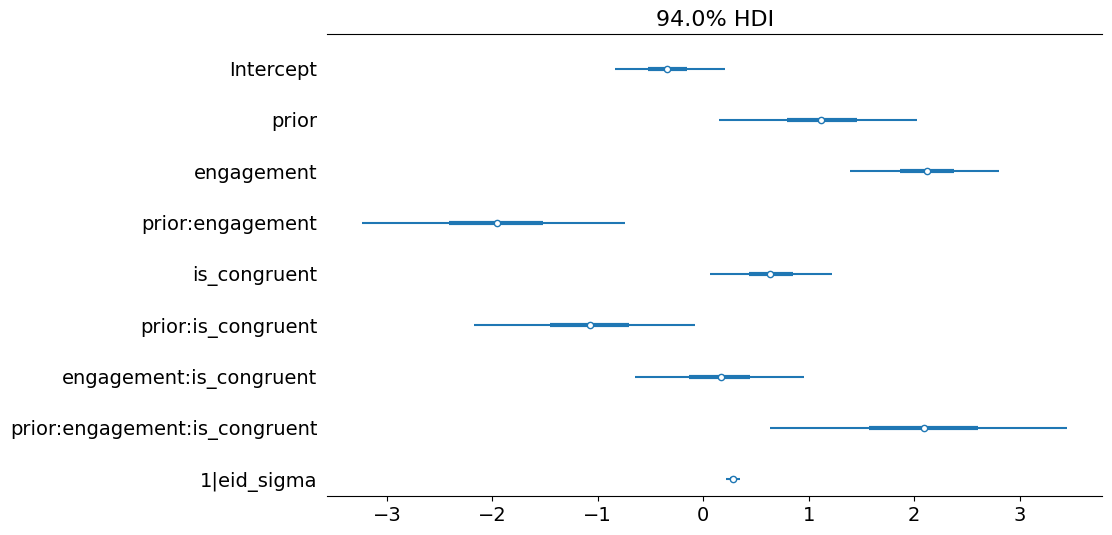

In [11]:
az.plot_forest(results, var_names=["~1|eid"], combined=True, figsize=(10, 6))

### Reaction time analyses

In [12]:
cleaned_grand_df = grand_df.dropna(subset=["rt"]).copy()

In [ ]:
cleaned_grand_df["rt"][cleaned_grand_df["rt"] < 0] = 0 # fix this

In [16]:
cleaned_grand_df

,engagement,rt,probabilityLeft,feedbackType,signcont,choice,prior,is_correct,eid,actual_reward_side,block_side,is_congruent
90,0.717114,0.147083,0.8,1.0,-1.0000,-1.0,0.561438,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,-1.0,1,0
91,0.675498,0.219072,0.8,1.0,0.0625,1.0,0.523604,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1
93,0.644552,0.698741,0.8,1.0,0.0000,1.0,0.518259,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1
94,0.655396,0.000000,0.8,1.0,0.0625,1.0,0.550723,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1
95,0.678703,0.000000,0.8,1.0,0.2500,1.0,0.580999,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
830,0.432515,3.623833,0.2,-1.0,0.1250,-1.0,0.574108,0,d2918f52-8280-43c0-924b-029b2317e62c,1.0,-1,0
831,0.418780,6.983933,0.2,1.0,-1.0000,-1.0,0.542445,1,d2918f52-8280-43c0-924b-029b2317e62c,-1.0,-1,1
832,0.324185,0.000000,0.2,1.0,-1.0000,-1.0,0.512528,1,d2918f52-8280-43c0-924b-029b2317e62c,-1.0,-1,1
835,0.285164,0.209967,0.2,1.0,1.0000,1.0,0.487471,1,d2918f52-8280-43c0-924b-029b2317e62c,1.0,-1,0


In [ ]:
cleaned_grand_df["log_rt"] = np.log(cleaned_grand_df["rt"])

In [ ]:
cleaned_grand_df["contrast"] = np.abs(cleaned_grand_df["signcont"])

In [79]:
cleaned_grand_df.head()

,engagement,rt,probabilityLeft,feedbackType,signcont,choice,prior,is_correct,eid,actual_reward_side,block_side,is_congruent,log_rt,contrast
90,0.717114,0.147083,0.8,1.0,-1.0000,-1.0,0.561438,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,-1.0,1,0,-1.916756,1.0000
91,0.675498,0.219072,0.8,1.0,0.0625,1.0,0.523604,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,-1.518356,0.0625
93,0.644552,0.698741,0.8,1.0,0.0000,1.0,0.518259,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,-0.358475,0.0000
96,0.683744,0.668588,0.8,-1.0,-0.0625,1.0,0.609235,0,6713a4a7-faed-4df2-acab-ee4e63326f8d,-1.0,1,0,-0.402587,0.0625
97,0.702716,0.179104,0.8,1.0,0.2500,1.0,0.635568,1,6713a4a7-faed-4df2-acab-ee4e63326f8d,1.0,1,1,-1.719790,0.2500


In [80]:
formula = """
    log_rt ~ contrast * engagement 
           + prior * is_congruent * engagement
"""
model_rt = smf.mixedlm(formula, data=cleaned_grand_df, groups=cleaned_grand_df["eid"])

In [81]:
results_rt = model_rt.fit()

In [82]:
print(results_rt.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      log_rt     
No. Observations:       20846        Method:                  REML       
No. Groups:             51           Scale:                   1.6801     
Min. group size:        171          Log-Likelihood:          -35115.5578
Max. group size:        824          Converged:               Yes        
Mean group size:        408.7                                            
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      0.755    0.215   3.519 0.000  0.335  1.176
contrast                      -1.199    0.108 -11.100 0.000 -1.411 -0.988
engagement                    -2.900    0.257 -11.265 0.000 -3.405 -2.395
contrast:engagement            0.639    0.146   4.373 0.